In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ✅ Matplotlib 폰트 캐시 파일 경로 확인 후 삭제
font_cache_path = os.path.expanduser("~/.matplotlib/fontList.json")
if os.path.exists(font_cache_path):
    os.remove(font_cache_path)
    print("✅ Matplotlib 폰트 캐시 삭제 완료!")
else:
    print("⚠️ 캐시 파일이 없습니다.")

# ✅ 한글 폰트 설정
def set_korean_font():
    font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font7/bad9b4bf17cf1669dde54184ba4431c22dcad27b.asset/AssetData/NanumGothic.ttc"  # 리눅스 환경 (Mac/Windows 사용자는 폰트 경로 확인)
    try:
        font_prop = fm.FontProperties(fname=font_path)
        plt.rc("font", family=font_prop.get_name())  # Matplotlib 전체 폰트 적용
        plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
        print(f"✅ 한글 폰트 설정 완료: {font_prop.get_name()}")
    except:
        print("🚨 폰트 설정 실패! 폰트 경로를 확인하세요.")

set_korean_font()


⚠️ 캐시 파일이 없습니다.
✅ 한글 폰트 설정 완료: Nanum Gothic


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./kr_population.csv', index_col=0, parse_dates=True)
df[:15]


,population,birth,death,increments,birthrate
Year,,,,,
1925-01-01,12997611,558897,359042,199855,6.59
1926-01-01,13052741,511667,337948,173719,NaN
1927-01-01,13037169,534524,353818,180706,NaN
1928-01-01,13105131,566142,357701,208441,NaN
1929-01-01,13124279,566969,414366,152603,NaN
1930-01-01,13880469,587144,322611,264533,6.41
1931-01-01,13895052,589428,346800,242628,NaN
1932-01-01,14117191,600545,384287,216258,NaN
1933-01-01,14229277,607021,336232,270789,NaN


In [3]:
# 10개씩 묶어서 평균을 계산
df['birth'].rolling(window=10).mean()[:15]

Year
1925-01-01         NaN
1926-01-01         NaN
1927-01-01         NaN
1928-01-01         NaN
1929-01-01         NaN
1930-01-01         NaN
1931-01-01         NaN
1932-01-01         NaN
1933-01-01         NaN
1934-01-01    574047.2
1935-01-01    582773.3
1936-01-01    595542.1
1937-01-01    605773.6
1938-01-01    606089.3
1939-01-01    607940.6
Name: birth, dtype: float64

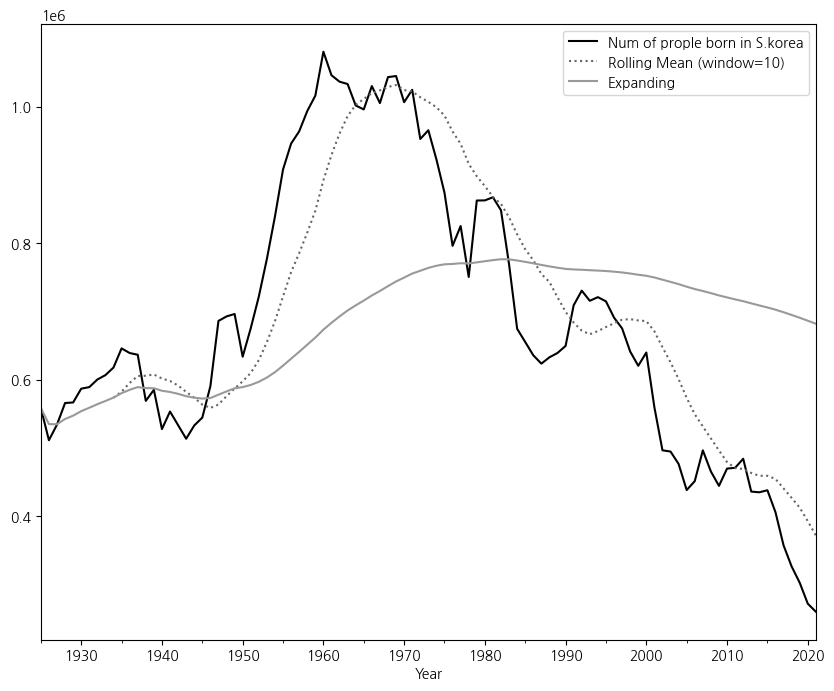

In [4]:
plt.style.use('grayscale')
plt.figure(facecolor='white')

# 연도별 출생자수
df['birth'].plot(label='Num of prople born in S.korea',
                 linestyle='-', figsize=(10,8))

# 연도별 출생자수 10년 이동 평균해, 선을 부드럽게 그리기
df['birth'].rolling(window=10).mean().plot(label='Rolling Mean (window=10)', 
                 linestyle=":")

# 누적 평균 그리기
df['birth'].expanding().mean().plot(label='Expanding', linestyle="-")
plt.legend()

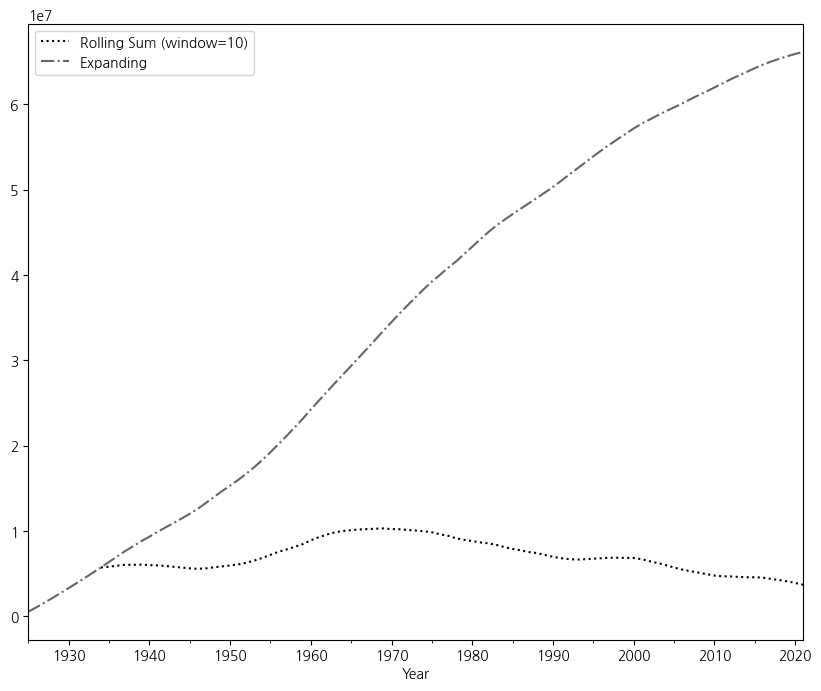

In [5]:
plt.style.use('grayscale')
plt.figure(facecolor='white')

# 10년간 누적 출생자수 계산
df['birth'].rolling(window=10).sum().plot(label='Rolling Sum (window=10)',
                  linestyle=":", figsize=(10,8))

# 누적 출생자수를 그리기
df['birth'].expanding().sum().plot(label='Expanding', linestyle="-.")
plt.legend()

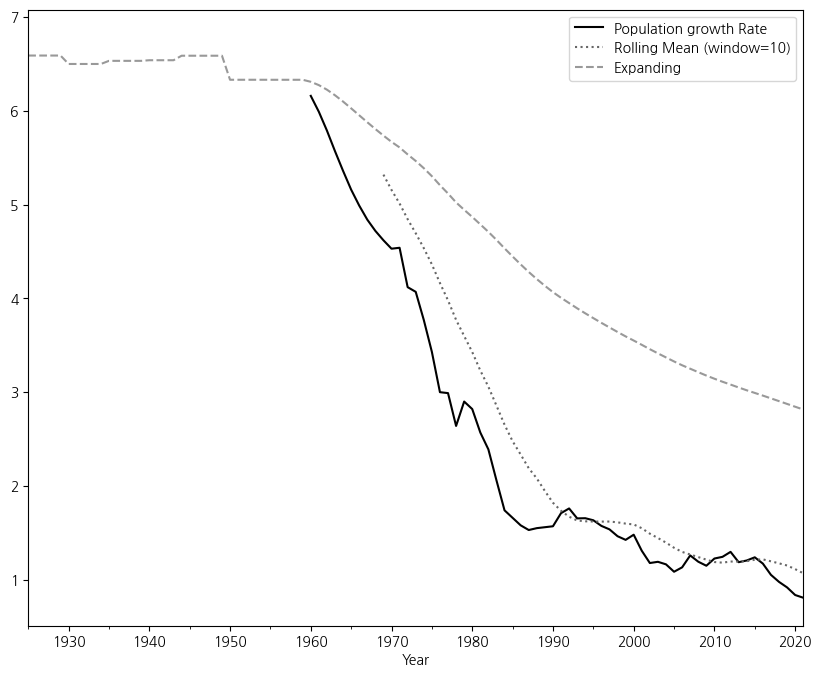

In [6]:
plt.style.use('grayscale')
plt.figure(facecolor='white')

# 연도별 출산율
df['birthrate'].plot(label='Population growth Rate', 
                  linestyle='-', figsize=(10,8))

# 연도별 출산율 10년 이동 평균해, 선을 부드럽게 그리기
df['birthrate'].rolling(window=10).mean().plot(
                 label='Rolling Mean (window=10)', linestyle=":")

# 누적 평균을 그리기
df['birthrate'].expanding().mean().plot(label='Expanding', linestyle="--")
plt.legend()

/var/folders/0p/p1yx5lj17yx384d74tkfr6480000gn/T/ipykernel_30781/1490248834.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['birthrate'].fillna(method='ffill').plot(label='Population growth Rate',
/var/folders/0p/p1yx5lj17yx384d74tkfr6480000gn/T/ipykernel_30781/1490248834.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['birthrate'].fillna(method='ffill').rolling(window=10).mean().plot(
/var/folders/0p/p1yx5lj17yx384d74tkfr6480000gn/T/ipykernel_30781/1490248834.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['birthrate'].fillna(method='ffill').expanding().mean().plot(


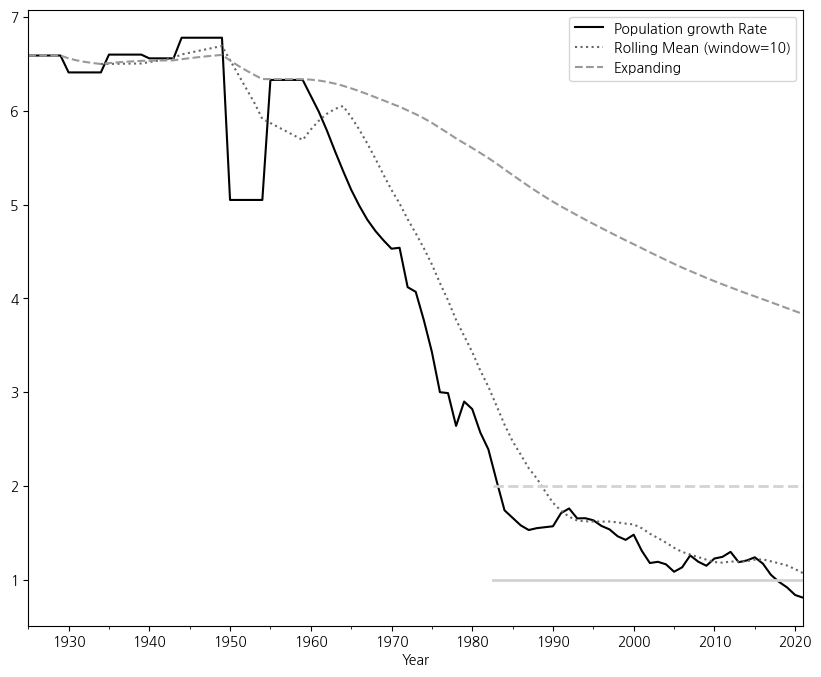

In [7]:
plt.style.use('grayscale')
plt.figure(facecolor='white')

# fillna로 결측치 채우기
# 연도별 출산율
df['birthrate'].fillna(method='ffill').plot(label='Population growth Rate',
                 linestyle='-', figsize=(10,8))

# 연도별 출산율 10년 이동 평균해, 선을 부드럽게 그리기
df['birthrate'].fillna(method='ffill').rolling(window=10).mean().plot(
            label='Rolling Mean (window=10)', linestyle=":")

# 누적 평균을 그리기
df['birthrate'].fillna(method='ffill').expanding().mean().plot(
                 label='Expanding', linestyle="--")

plt.axhline(y=2.0, xmin=0.6, xmax=1.0, color='lightgray',
                  linestyle='--', linewidth=2)
plt.axhline(y=1.0, xmin=0.6, xmax=1.0, color='lightgray',
                  linestyle='-', linewidth=2)

plt.legend()
plt.show()

---

### 📌 지수 이동 평균(Exponential Moving Average, EMA) 검증 방법   

최근 데이터에 더 높은 가중치를 부여하여 변화를 민감하게 반영하는 이동 평균 방법   


검증 방법에는 두 가지가 있다.   

***1. 이론적 검증***   
***2. 실제 데이터 검증***

In [8]:
df.columns

Index(['population', 'birth', 'death', 'increments', 'birthrate'], dtype='object')

In [9]:
df.index

DatetimeIndex(['1925-01-01', '1926-01-01', '1927-01-01', '1928-01-01',
               '1929-01-01', '1930-01-01', '1931-01-01', '1932-01-01',
               '1933-01-01', '1934-01-01', '1935-01-01', '1936-01-01',
               '1937-01-01', '1938-01-01', '1939-01-01', '1940-01-01',
               '1941-01-01', '1942-01-01', '1943-01-01', '1944-01-01',
               '1945-01-01', '1946-01-01', '1947-01-01', '1948-01-01',
               '1949-01-01', '1950-01-01', '1951-01-01', '1952-01-01',
               '1953-01-01', '1954-01-01', '1955-01-01', '1956-01-01',
               '1957-01-01', '1958-01-01', '1959-01-01', '1960-01-01',
               '1961-01-01', '1962-01-01', '1963-01-01', '1964-01-01',
               '1965-01-01', '1966-01-01', '1967-01-01', '1968-01-01',
               '1969-01-01', '1970-01-01', '1971-01-01', '1972-01-01',
               '1973-01-01', '1974-01-01', '1975-01-01', '1976-01-01',
               '1977-01-01', '1978-01-01', '1979-01-01', '1980-01-01',
      

In [10]:
import matplotlib.font_manager as fm

# 폰트 설정
font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font7/bad9b4bf17cf1669dde54184ba4431c22dcad27b.asset/AssetData/NanumGothic.ttc"
font_prop = fm.FontProperties(fname=font_path)

# Matplotlib 설정
plt.rcParams["font.family"] = font_prop.get_name()  # Nanum Gothic 적용
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


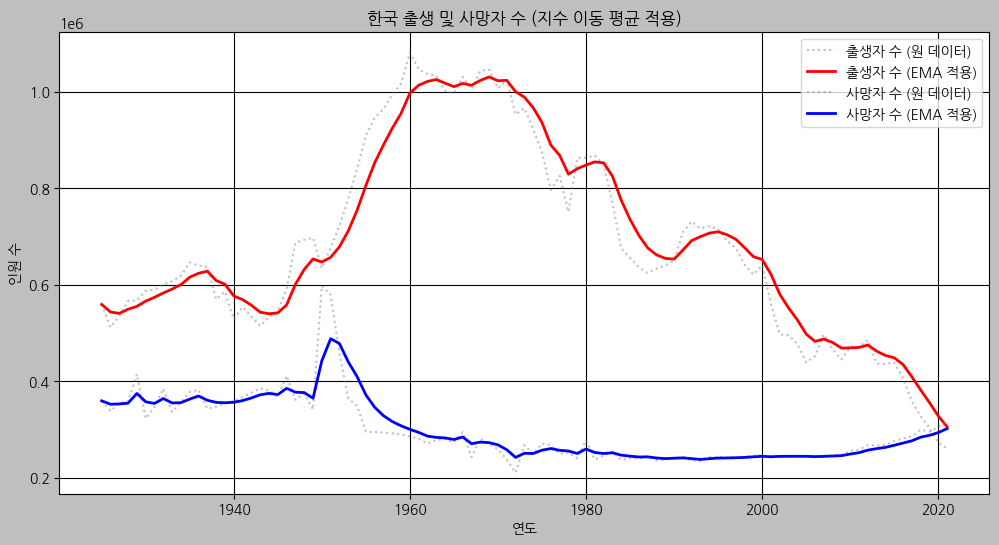

In [11]:
# 지수 이동 평균(EMA) 계산 (반감기 설정: span=5)
df["birth_ema"] = df["birth"].ewm(span=5, adjust=False).mean()
df["death_ema"] = df["death"].ewm(span=5, adjust=False).mean()

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["birth"], label="출생자 수 (원 데이터)", alpha=0.5, linestyle="dotted", color='gray')
plt.plot(df.index, df["birth_ema"], label="출생자 수 (EMA 적용)", linewidth=2, color='red')

plt.plot(df.index, df["death"], label="사망자 수 (원 데이터)", alpha=0.5, linestyle="dotted", color='gray')
plt.plot(df.index, df["death_ema"], label="사망자 수 (EMA 적용)", linewidth=2, color='blue')

plt.title("한국 출생 및 사망자 수 (지수 이동 평균 적용)")
plt.xlabel("연도")
plt.ylabel("인원 수")
plt.legend()
plt.grid(True)

# 그래프 출력
plt.show()
